# Baseline Star ARIMA

- We established previously that ARIMA makes very poor predictions of the solar data.
- To establish a baseline against which to compare the GPR predictions on the baseline stars we have, I will perform ARIMA on that data here.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time
from statsmodels.tsa.arima.model import ARIMA
from matplotlib.ticker import MultipleLocator
from scipy.stats import boxcox

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))
from helpers.df_ops import prepare_df, split_df, clean_df

In [20]:
datapath = r"../../Data/benchmark/HD201091_Mt_wilson_data.txt"
add_prefix = False
relative = True

train_split = 0.8
valid_split = 0.99-train_split

verbose_clean = True
plot_clean = True


In [21]:
# Read the data into a "raw" df
raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

- Now perform the interpolations.

In [22]:
# Downsample before split

data_df_year = data_df.resample('YE').median().interpolate('time', limit =5) # resample years into groups, asfreq takes one per group 
data_df_6me = data_df.resample('6ME').median().interpolate('time', limit = 6)
data_df_me = data_df.resample('ME').median().interpolate('time', limit = 6)

Removed 0 datapoints which had NaN.
Removed 0 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


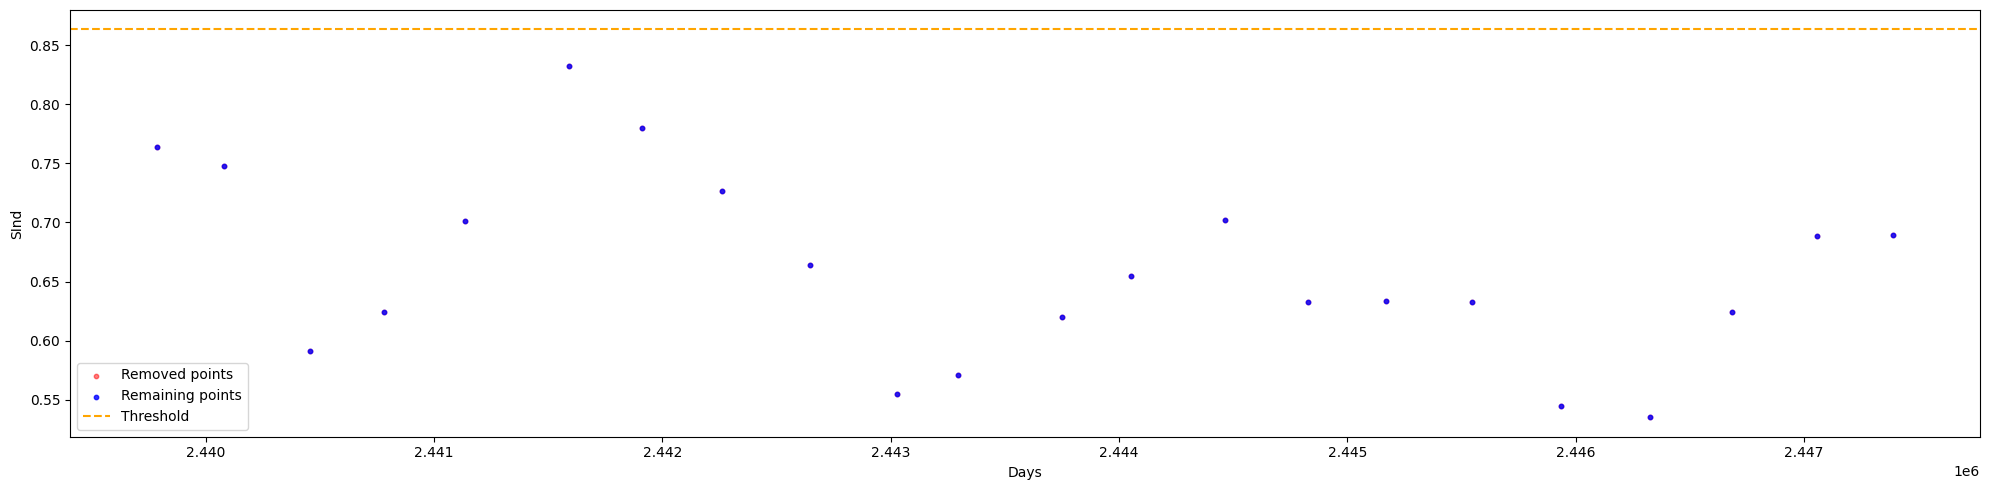

Removed 4 datapoints which had NaN.
Removed 5 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


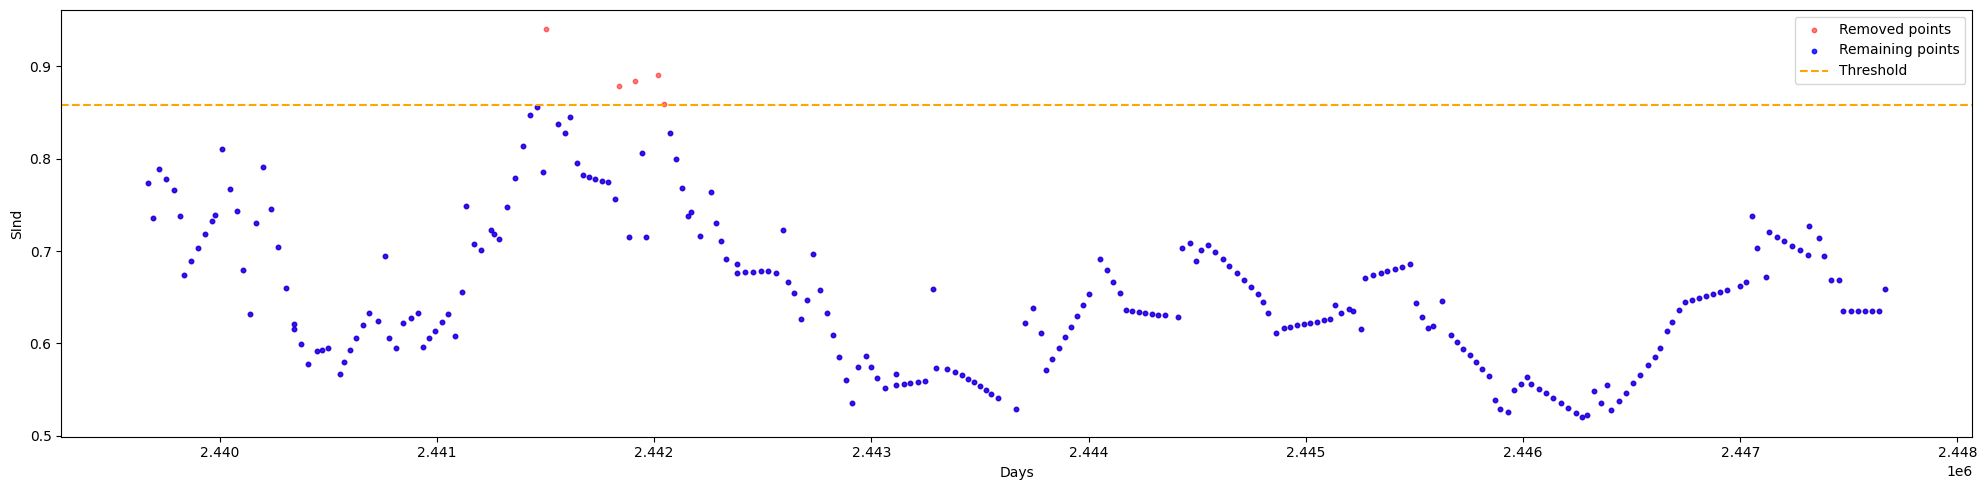

Removed 0 datapoints which had NaN.
Removed 0 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


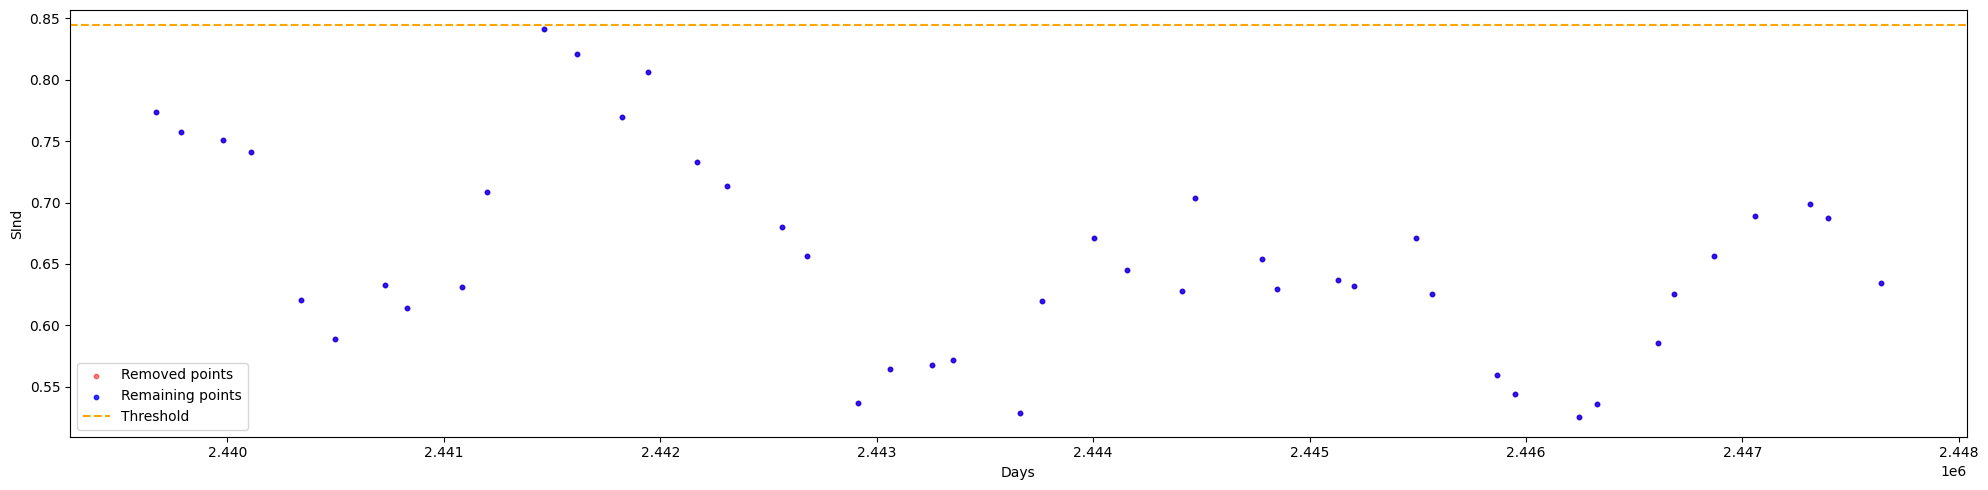

In [23]:
# Split the data
dirty_train_df_year, valid_df_year, test_df_year = split_df(data_df_year,
                                                train_split=train_split, valid_split=valid_split)
dirty_train_df_me, valid_df_me, test_df_me = split_df(data_df_me,
                                                train_split=train_split, valid_split=valid_split)
dirty_train_df_6me, valid_df_6me, test_df_6me = split_df(data_df_6me,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df_year = clean_df(dirty_train_df_year, tol=4,
                        verbose=verbose_clean, plot=plot_clean)
train_df_me = clean_df(dirty_train_df_me, tol=4,
                        verbose=verbose_clean, plot=plot_clean)
train_df_6me = clean_df(dirty_train_df_6me, tol=4,
                        verbose=verbose_clean, plot=plot_clean)

- ARIMA only works for stationary data: check this is the case.
- Data is pretty sparse cannot tell if stationary just by looking at it. Try plotting the data to see if variance is ok.


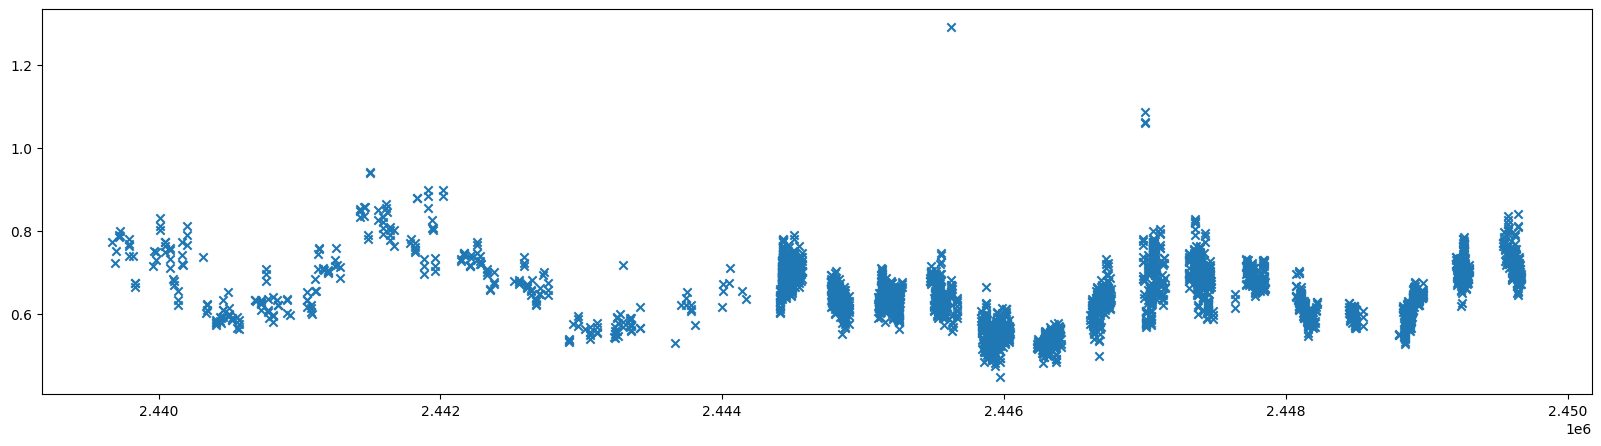

In [24]:
fig, ax = plt.subplots(figsize=(20,5))
plt.scatter(data_df["day"], data_df['sind'], marker='x')

- The variance does not seem constant this might be a problem. Perhaps it will be best to take the log.

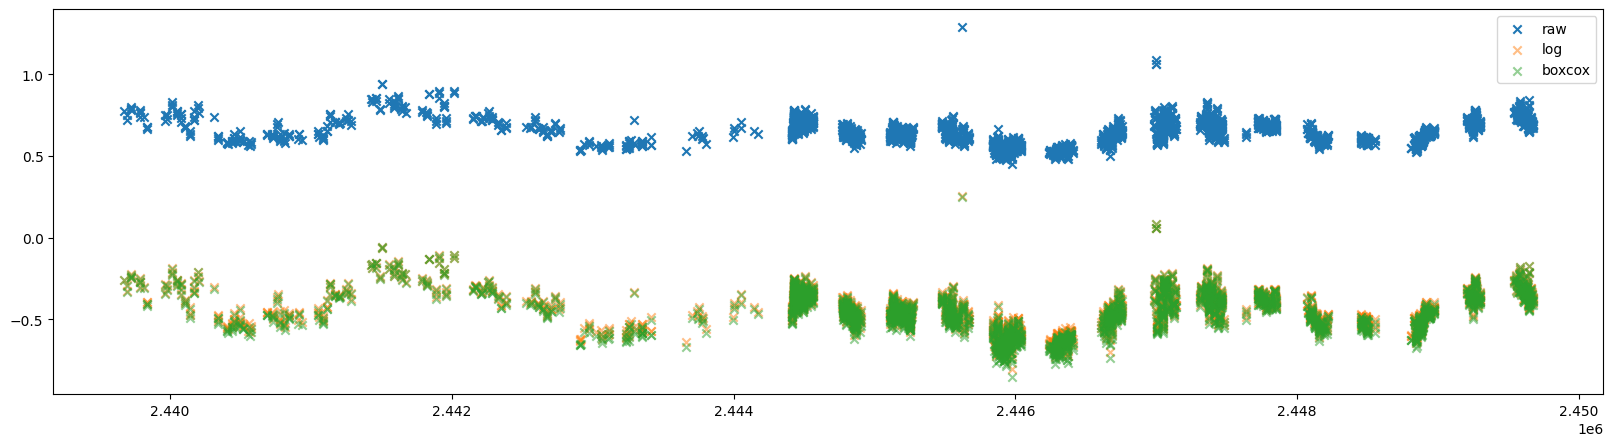

In [25]:
fig, ax = plt.subplots(figsize=(20,5))
plt.scatter(data_df["day"], data_df['sind'], marker='x', label='raw')

plt.scatter(data_df["day"], np.log(data_df['sind']), marker='x', label = 'log', alpha=0.5)

data_df['sind_bc'], lambda_ = boxcox(data_df['sind'])

plt.scatter(data_df["day"], data_df['sind_bc'], marker='x', label='boxcox', alpha=0.5)

plt.legend()


- Let's use the BoxCox transform here.

In [27]:
train_df_year['sind_bc'], lambda_year = boxcox(train_df_year['sind'])
train_df_6me['sind_bc'], lambda_6me = boxcox(train_df_6me['sind'])
train_df_me['sind_bc'], lambda_me = boxcox(train_df_me['sind'])

- Examine them with little plots

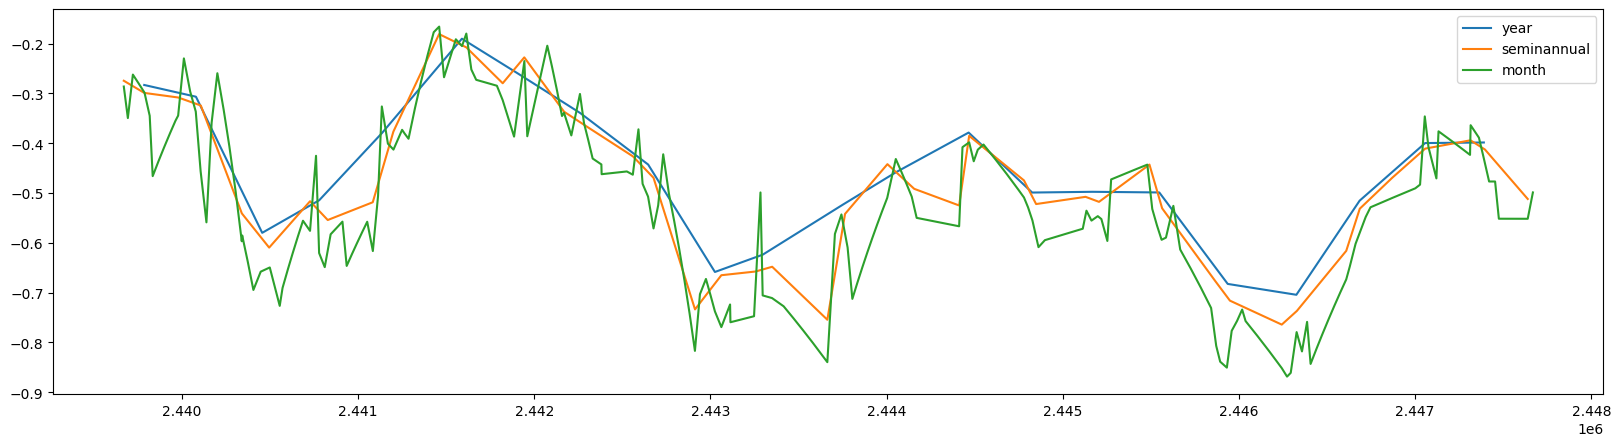

In [33]:
fig, ax = plt.subplots(figsize=(20,5))

ax.plot(train_df_year['day'], train_df_year['sind_bc'], label = 'year')
ax.plot(train_df_6me['day'], train_df_6me['sind_bc'], label = 'seminannual')
ax.plot(train_df_me['day'], train_df_me['sind_bc'], label = 'month')

ax.legend()